EJERCICIO1_DESCRIPTIVO

OUTPUTS:

* ej1_descriptivo.csv: Tabla de estadísticos descriptivos de todas las variables numéricas
(pandas describe)

* ej1_histogramas.png: Histogramas

* ej1_boxplots.png: Boxplots de la variable objetivo por cada variable categórica

* ej1_heatmap_correlacion.png: Mapa de calor de la matriz de correlaciones

* ej1_categoricas.png: Gráficos de frecuencia de las variables categóricas


,valor
Nº filas,11352
Nº columnas,28
Tamaño en memoria,13561740


,col_type,elements,unique,missing,rate_missing
Year,float64,11350,21,2,0.02
Gender,str,11351,2,1,0.01
Age,str,11331,158,21,0.18
1.Body Weight (kg),str,11341,370,11,0.10
2.Stature height (cm),str,11350,258,2,0.02
3.The height of the root of the nose in standing (cm),str,4855,239,6497,57.23
4.Height of shoulders in standing position (cm),str,4860,242,6492,57.19
5.Height of the elbow in standing position (cm),str,4845,228,6507,57.32
6.The height of the tip of the 3rd finger in standing position (cm),str,4832,225,6520,57.43
7.Arm's reach in standing position (cm),str,9674,458,1678,14.78


,age,weight,height,shoulder_height,arms_reach,leg_length
count,4697.000000,4697.000000,4697.000000,4697.000000,4697.000000,4697.000000
mean,22.196296,71.304237,175.859336,147.058484,174.649116,105.082606
std,6.026330,14.185204,9.368418,8.950201,11.613725,8.173939
min,12.000000,40.000000,145.000000,114.000000,133.000000,80.000000
25%,19.000000,60.000000,169.000000,140.000000,167.000000,100.000000
50%,21.000000,70.000000,176.000000,147.000000,175.000000,105.000000
75%,22.000000,80.000000,183.000000,153.000000,183.000000,110.000000
max,81.000000,121.900000,204.000000,179.000000,212.000000,130.000000
var,36.316656,201.220014,87.767260,80.106091,134.878611,66.813286
mode,19.000000,70.000000,180.000000,150.000000,180.000000,110.000000


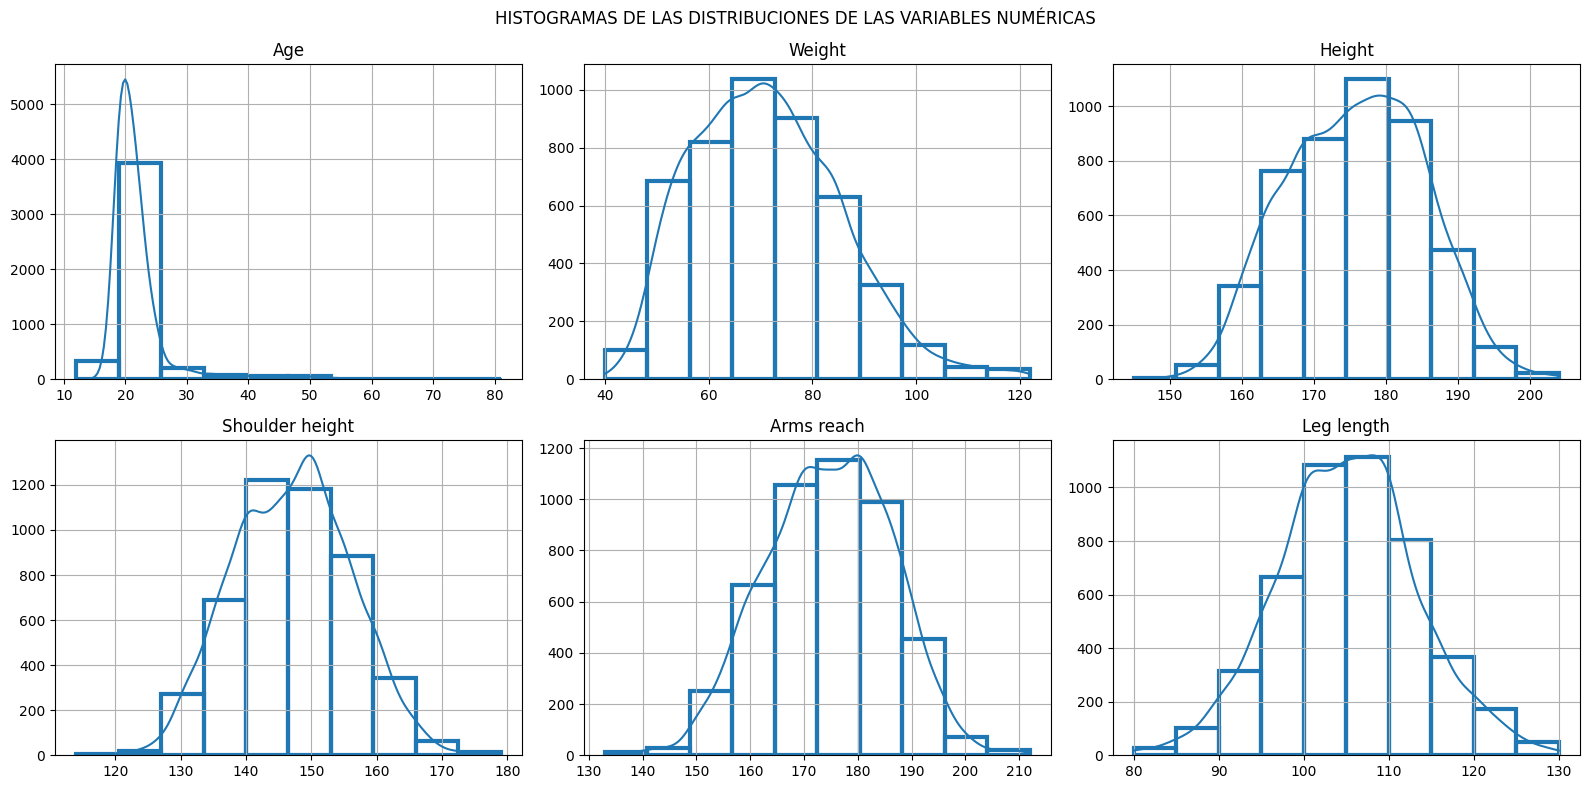

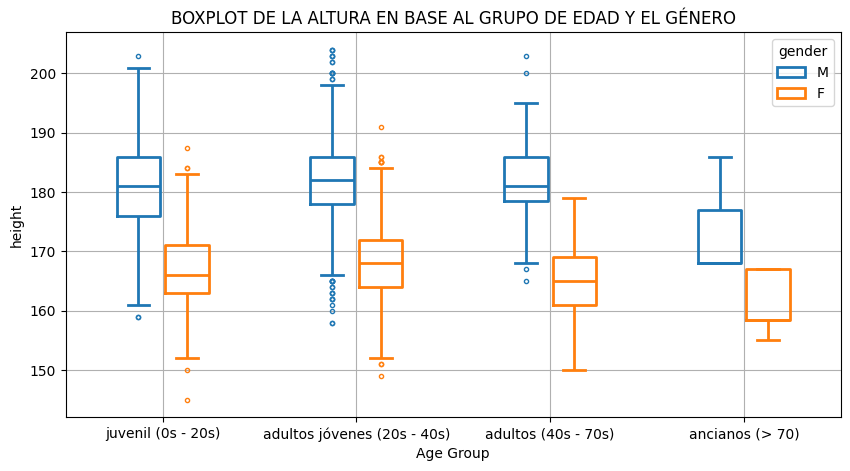

,Absoluta,Relativa
F,1933,41.153928
M,2764,58.846072


,Absoluta,Relativa
adultos jóvenes (20s - 40s),3218,68.511816
adultos (40s - 70s),138,2.938046
juvenil (0s - 20s),1333,28.379817
ancianos (> 70),8,0.170321


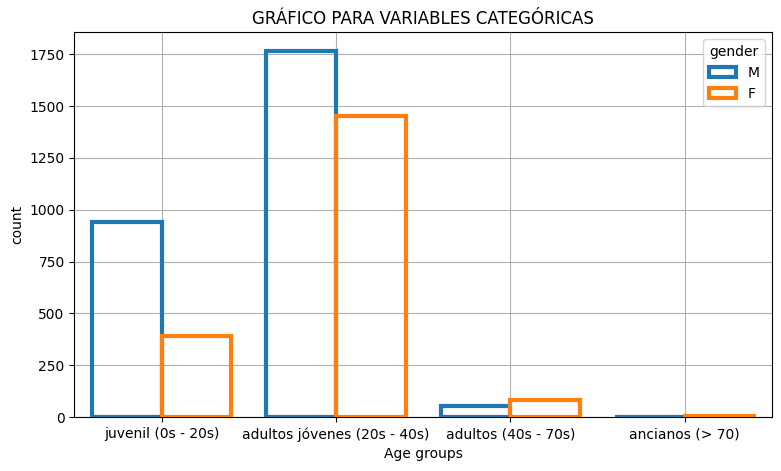

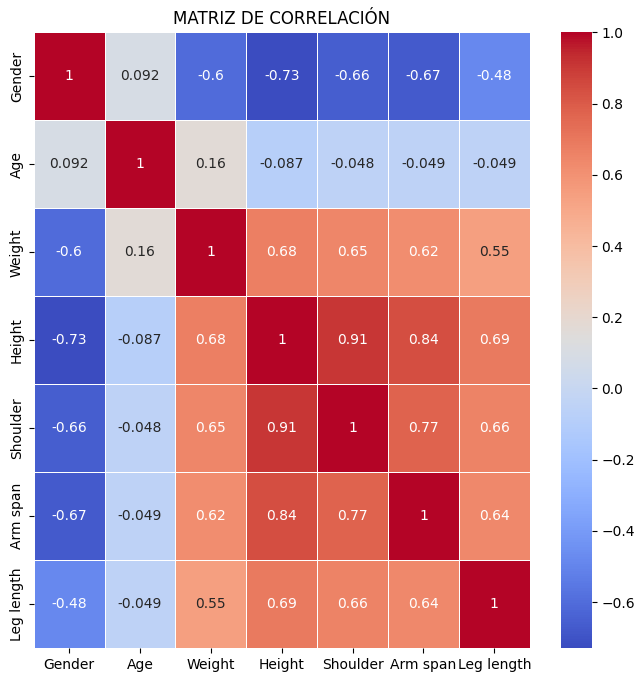

In [2]:
# =============================================================================
# PRÁCTICA FINAL — EJERCICIO 1
# Análisis Estadístico Descriptivo
# =============================================================================

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display



# ------------------------------------------------------------------------------------------------------
# RESUMEN ESTRUCTURAL
# ------------------------------------------------------------------------------------------------------

# Número de filas, columnas y tamaño en memoria.
# Tipos de dato de cada columna (dtypes).
# Porcentaje de valores nulos por columna y decisión de tratamiento

# 1. Volumen del df
def resumen_estructural(data: pd.DataFrame) -> pd.DataFrame:

    """
    Devuelve un DataFrame con:
        * Número de filas
        * Número columnas 
        * El tamaño en memoria del DataFrame
    """

    resumen = {
        'Nº filas': data.shape[0],
        'Nº columnas': data.shape[1],
        'Tamaño en memoria': data.memory_usage(deep=True).sum()
    }

    return pd.DataFrame.from_dict(resumen, orient='index', columns=['valor'])


# 2. Descripción de los datos del df
def tipos_datos(data: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve un DataFrame con:
        * Nombre columna
        * Tipo de dato
        * Total de datos
        * Duplicados
        * Nulos 
    """
    n = len(data)

    resumen_df = pd.DataFrame({
        'col_type': data.dtypes,
        'elements': data.count(),
        'unique': data.nunique(),
        'missing': data.isna().sum(),
        'rate_missing': round(100 * data.isna().sum() / n, 2)
    })
    resumen_df.index = data.columns

    return resumen_df



# ------------------------------------------------------------------------------------------------------
# LIMPIEZA PREVIA
# ------------------------------------------------------------------------------------------------------

# Antes de seguir con el ejercicio es necesario limpiar el dataset

# 1. Eliminar columnas
def eliminar_cols(data: pd.DataFrame, column_names: list) -> pd.DataFrame:

    """
    Elimina columnas innecesarias.

    Variables:
        * data: DataFrame base
        * column_names: lista de columnas del nuevo DataFrame

    Output:
        * DataFrame con sólo las columnas especificadas
    """

    return data[column_names]


# 2. Eliminar nulos (en este caso, al ser > 50% datos nulos, se eliminan directamente)
def eliminar_nulls(data: pd.DataFrame) -> pd.DataFrame:

    """
    Elimina todas las filas con algún elemento nulo.
    """

    return data.dropna()


# 3. Cambiar type
def cambiar_type(data: pd.DataFrame, change_dict: dict) -> pd.DataFrame:

    """
    Cambia el tipo de las columnas de un DataFrame.

    Variables:
        * data: DataFrame base
        * change_dict: diccionario con nombres de columnas y sus nuevos tipos

    Output:
        * DataFrame
    """

    for column, correct_type in change_dict.items():
        
        if column not in data.columns:
            raise ValueError(f"Column {column} does not exist.")
        
        if change_dict[column] == 'float':
            data[column] = data[column].astype(str).str.replace(r',', '.').str.replace(' kg', '').str.replace(' cm', '')
        
        data[column] = data[column].astype(correct_type)

    return data


# 4. Limpieza del df
def limpiar_df(data: pd.DataFrame, column_names: list, change_dict: dict, new_names: None) -> pd.DataFrame:

    """
    Limpieza de DataFrame:
        * Selecciona solo columnas especificadas
        * Elimina elementos nulos
        * Se renombran las columnas (si se especifican)
        * Cambia tipos de columnas

    Variables:
        * data: DataFrame
        * column_names: lista de columnas del nuevo DataFrame
        * change_dict: diccionario con nombres de columnas y sus nuevos tipos
        * new_names: lista con los nuevos nombres para las columnas del DataFrame (si != None)

    Output:
        * DataFrame 
    """
    
    data_red = eliminar_cols(data, column_names)

    data_red = eliminar_nulls(data_red)

    # Renombrando columnas
    if new_names != None:
        data_red.columns = new_names

    data_clean = cambiar_type(data_red, change_dict)


    return data_clean



# ------------------------------------------------------------------------------------------------------
# ESTADÍSTICOS DESCRIPTIVOS
# ------------------------------------------------------------------------------------------------------

# Media, mediana, moda, desviación típica, varianza, mínimo, máximo y cuartiles.
# Rango intercuartílico (IQR) de la variable objetivo.
# Coeficiente de asimetría (skewness) y curtosis para al menos la variable objetivo


# 1. Ampliación de .describe() para incluir todos los estadísticos
def est_descriptivos(data: pd.DataFrame) -> pd.DataFrame:

    """
    Calcula los estadísticos descriptivos de las columnas numéricas del DataFrame.

    Usa como base el output de pandas describe y añade varianza, moda, IQR, skewness y curtosis.

    Lo guarda en "output\\ej1_descriptivo.csv".
    """

    medidas = data.describe()

    medidas.loc['var'] = [data[column].var() for column in medidas.columns]
    medidas.loc['mode'] = [data[column].mode()[0] for column in medidas.columns]
    medidas.loc['IQR'] = [medidas[column].loc['75%'] - medidas[column].loc['25%'] for column in medidas.columns]
    medidas.loc['skewness'] = [skew(data[column]) for column in medidas.columns]
    medidas.loc['kurtosis'] = [kurtosis(data[column]) for column in medidas.columns]

    # medidas.to_csv('output\\ej1_decriptivo.csv')

    return medidas


# Los resultados hasta ahora, sobre todo para skewness y kurtosis, indican una gran irregularidad en los datos.
# Posteriormente se verá que se debe a ciertos outliers que en nada tienen que ver con el resto de valores de sus columnas.



# ------------------------------------------------------------------------------------------------------
# DISTRIBUCIONES
# ------------------------------------------------------------------------------------------------------

# Histogramas de todas las variables numéricas
# Boxplots de la variable objetivo, segmentados por cada variable categórica.
# Detección y tratamiento de outliers (método IQR o Z-score; justifica cuál usas).


# 1. Funciones para detectar y eliminar outliers
def detectar_outliers(data: pd.DataFrame, column: str):

    """
    Detecta outliers en una columna usando el método IQR.
    
    Devuelve el índice de los outliers.
    """

    q1, q3 = data[column].quantile(0.25), data[column].quantile(0.75)
    iqr = q3 - q1

    min_limit = q1 - 2 * iqr
    max_limit = q3 + 2 * iqr

    outliers_index = data[(data[column] < min_limit) | (data[column] > max_limit)].index

    return outliers_index


def eliminar_outliers(data: pd.DataFrame):

    """
    Elimina los outliers del DataFrame.

    * Variable 'age': descarta las edades menores a 0
    * Variable 'gender': descarta cualquier valor que no sea M o F
    * Variable 'year': descarta los años que no estén entre 2003 y 2023
    * Otras variables (antropométricas): descarta los índices devueltos por detectar_outliers()

    Devuelve el DataFrame sin outliers.
    """

    indexes = []

    for column in list(data.columns):
        if column == 'age':
            i = data[data['age'] < 0].index
        elif column == 'gender':
            i = data[~ data['gender'].isin(['M', 'F'])].index
        elif column == 'year':
            i = data[(data['year'].astype('float') < 2003) | (data['year'].astype('float') > 2023)]
        else:
            i = detectar_outliers(data, column)
        
        indexes.extend(i)

    return data.loc[~ data.index.isin(indexes)]


# 2. Histogramas
def plot_density(data: pd.DataFrame, hist_bins = 10):

    """
    Grafica los histogramas de todas las variables numéricas del DataFrame.

    Las guarda en "output\\ej1_histogramas.png".
    """

    numeric_data = data.select_dtypes(include=['number'])
    n = len(numeric_data.columns)

    fig, axes = plt.subplots(2, int(n/2), figsize = (16, 8))
    axes = axes.flatten()
    
    for column, ax in zip(numeric_data.columns, axes):
        sns.histplot(data = data, x = column, kde=True, bins=hist_bins, ax=ax, fill = False, linewidth = 3,edgecolor = 'steelblue')
        ax.set_title(column.replace('_', ' ').capitalize())
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.grid()
    
    plt.suptitle('HISTOGRAMAS DE LAS DISTRIBUCIONES DE LAS VARIABLES NUMÉRICAS')
    plt.tight_layout()
    plt.savefig("output\\ej1_histogramas.png")
    plt.show()

    

# 3. Boxplot

# Función para clasificar edades
def set_age_group(age: int):

    """
    Clasifica una edad en uno de los 4 cuatro grupos.

    Devuelve el grupo.
    """

    if age < 20:
        group = 'juvenil (0s - 20s)'
    elif age < 40:
        group = 'adultos jóvenes (20s - 40s)'
    elif age < 70:
        group = 'adultos (40s - 70s)'
    else:
        group = 'ancianos (> 70)'

    return group


# Función para el boxplot
def plot_boxplot(data: pd.DataFrame, column: str):

    """
    Grafica el boxplot de los valores de una columna dada.

    Toma como variables categóricas 'age_group' y 'gender'.

    Guarda el resultado en "output\\ej1_boxplots.png"
    """

    plt.figure(figsize = (10,5))
    sns.boxplot(x = data['age_group'], y = data[column], hue = data['gender'], fill=False, gap=.1, width=0.5, fliersize=3, linewidth = 2)
    plt.xlabel('Age Group')
    plt.ylabel(column.replace('_', ' '))
    plt.grid()
        
    plt.title('BOXPLOT DE LA ALTURA EN BASE AL GRUPO DE EDAD Y EL GÉNERO')
    # plt.savefig("output\\ej1_boxplots.png")
    plt.show()
        


# ------------------------------------------------------------------------------------------------------
# VARIABLES CATEGÓRICAS
# ------------------------------------------------------------------------------------------------------

# Frecuencia absoluta y relativa de cada categoría.
# Gráfico de barras o de sectores para cada variable categórica.
# Análisis de si alguna categoría domina el dataset (desbalance).


# 1. Frecuencias
def frecuencias(data: pd.DataFrame, column: str) -> pd.DataFrame:

    """
    Calcula las frecuencias absoluta y relativa de una variable categórica dada.

    Devuelve un DataFrame con los resultados.
    """

    n = len(data[column])

    freq = pd.DataFrame({})
    freq['Absoluta'] = [list(data[column]).count(element) for element in set(data[column])]
    freq['Relativa'] = 100 * freq['Absoluta'] / n

    freq.index = set(data[column])

    return freq


# 2. Countplot (análisis de los resultados en Respuestas.md)
def plot_barras(data: pd.DataFrame):

    """
    Grafica el countplot de 'age_group' usando 'gender' como hue.

    Guarda la gráfica en "output\\ej1_categoricas.png".
    """

    plt.figure(figsize = (9, 5))
    sns.countplot(data = data, x='age_group', hue='gender', linewidth = 3, zorder = 3, fill = False)
    plt.xlabel('Age groups')
    plt.ylabel('count')
    plt.grid()
    plt.title('GRÁFICO PARA VARIABLES CATEGÓRICAS')
    # plt.savefig("output\\ej1_categoricas.png")
    plt.show()



# ------------------------------------------------------------------------------------------------------
# CORRELACIONES
# ------------------------------------------------------------------------------------------------------

# Mapa de calor (heatmap) de la matriz de correlaciones de Pearson de las variables numéricas.
# Identificación de las tres variables con mayor correlación (en valor absoluto) con la variable objetivo.
# Detección de posible multicolinealidad entre predictoras (pares con |r| > 0,9).


# 1. Heatmap (análisis de los resultados en Respuestas.md)
def heatmap(data: pd.DataFrame):

    """
    Grafica el heatmap del DataFrame.

    * Convierte la columna 'gender' en binaria
    * Elimina 'age_group' (no será necesaria en el heatmap pues tenemos 'age')
    * Cambia el nombre de las columnas para mejor legibilidad
    * Grafica el heatmap junto con los coeficientes de correlación

    Guarda el resultado en "output\\ej1_heatmap.png".
    """

    data['gender'] = data['gender'].map({'M': 0, 'F': 1})

    data = data.drop(['age_group'], axis = 1)

    data.columns = ['Gender', 'Age','Weight' , 'Height', 'Shoulder', 'Arm span', 'Leg length']

    plt.figure(figsize = (8, 8))
    sns.heatmap(data.corr(), annot=True, linewidths=0.5, cmap = 'coolwarm')
    plt.title('MATRIZ DE CORRELACIÓN')
    # plt.savefig("output\\ej1_heatmap.png")
    plt.show()



# ------------------------------------------------------------------------------------------------------
# RESULTADO
# ------------------------------------------------------------------------------------------------------


def main():

    df = pd.read_csv("data\\anthropometric_2003_2023.csv")

    # Estructura
    display(resumen_estructural(df))
    display(tipos_datos(df))

    # Columnas con las que se va a trabajar
    cols = ['Gender', 
            'Age', 
            '1.Body Weight (kg)',
            '2.Stature height (cm)',
            '4.Height of shoulders in standing position (cm)', 
            "11.Arms spread in standing position (cm)",
            '20.Leg length when sitting forward (cm)']

    # Nuevos nombres de columnas
    col_nombres = ['gender', 'age', 'weight','height', 'shoulder_height', 'arms_reach', 'leg_length']

    # Diccionario con los tipos correctos de cada columna
    tipos_dict = {
        'gender': 'str',
        'age': 'float',
        'weight': 'float',
        'height': 'float', 
        'shoulder_height': 'float', 
        'arms_reach': 'float', 
        'leg_length': 'float'
    }

    # Limpieza
    df = limpiar_df(df, cols, tipos_dict, col_nombres)

    # Eliminación de outliers
    df = eliminar_outliers(df)

    # Se guardan los datos limpios para ejercicio_2
    # df.to_csv("data\\anthropometric_clean.csv", index = False)

    # Análisis descriptivo
    display(est_descriptivos(df))

    # Histogramas
    plot_density(df)

    # Se crea la columna age_group para trabajar mejor con las edades
    df['age_group'] = [set_age_group(age) for age in  df['age']]

    # Boxplot
    plot_boxplot(df, 'height')

    # Frecuencias de variables categóricas
    display(frecuencias(df, 'gender'))
    display(frecuencias(df, 'age_group'))

    # Countplot
    plot_barras(df)

    # Heatmap
    heatmap(df)

main()

In [ ]:
import numpy as np

